In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

test_metrics_special = pd.read_csv(
    # '../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2/test_metrics2.csv'
    '../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2_1022/test_metrics2.csv'
)

test_metrics_info_special = pd.read_csv(
    # '../dataset_m/data_split/combined_test_special.txt',
    '../dataset_m/data_split_1022/combined_test_special.txt',
    header=None, sep=',', names=['test_npz_colname_special']
)

test_metrics_info_special[['wind_speed', 'wind_direction', 'sc', 'test_source_number_special']] = \
    test_metrics_info_special['test_npz_colname_special'].str.extract(r'v([\d_]+)_d(\d+)_sc(\d+)_s(\d+)')

test_metrics_info_special['wind_speed'] = test_metrics_info_special['wind_speed'].str.replace('_', '.').astype(float)
test_metrics_info_special['wind_direction'] = test_metrics_info_special['wind_direction'].astype(int)
test_metrics_info_special['sc'] = test_metrics_info_special['sc'].astype(int)
test_metrics_info_special['test_source_number_special'] = test_metrics_info_special['test_source_number_special'].astype(int)
test_metrics_info_special['test_special_index'] = test_metrics_info_special.index
test_metrics_special = pd.concat([test_metrics_special, test_metrics_info_special], axis=1)

source_data = pd.read_csv('../dataset_m/ori_data/shp_point/source.csv')
df_xy_special = test_metrics_special.copy()

train_data = pd.read_csv(
    # '../dataset_m/data_split/combined_train.txt',
    '../dataset_m/data_split_1022/combined_train.txt',
                         header=None, names=['train_npz_colname'])

train_data[['wind_speed', 'wind_direction', 'sc', 'train_source_number']] = \
    train_data['train_npz_colname'].str.extract(r'v([\d_]+)_d(\d+)_sc(\d+)_s(\d+)')

train_data['wind_speed'] = train_data['wind_speed'].str.replace('_', '.').astype(float)
train_data['wind_direction'] = train_data['wind_direction'].astype(int)
train_data['sc'] = train_data['sc'].astype(int)
train_data['train_source_number'] = train_data['train_source_number'].astype(int)
train_data['train_index'] = train_data.index

unique_train_sources = train_data[['train_source_number']].drop_duplicates()
unique_train_sources = unique_train_sources.merge(
    source_data.rename(columns={'Src_grp': 'train_source_number'}),
    on='train_source_number',
    how='left'
)

coords_train = unique_train_sources[['x', 'y']].values
train_sources = unique_train_sources['train_source_number'].values
kdtree_train = cKDTree(coords_train)

def find_train_neighbors_special(row, wind_dir_list, wind_speed_list):
    (train_src,
     left_max_idx, left_max_col, left_min_idx, left_min_col,
     right_max_idx, right_max_col, right_min_idx, right_min_col) = None, None, None, None, None, None, None, None, None

    if row['wind_direction'] in (wind_dir_list):
        pt = source_data.loc[
            source_data['Src_grp'] == row['test_source_number_special'], ['x', 'y']
        ].values[0]
        _, idxs = kdtree_train.query(pt, k=1)
        train_src = train_sources[idxs]
        if row['wind_direction'] in (90, 270):
            target_left = (row['wind_direction'] - 30) % 360
            target_right = (row['wind_direction'] + 30) % 360
        else:
            target_left = (row['wind_direction'])
            target_right = (row['wind_direction'])
        ws_min = row['wind_speed'] - 0.5
        ws_max = row['wind_speed'] + 0.5

        # -------- Left Min--------
        cond_left_min = (
            (train_data['wind_speed'] == ws_min) &
            (train_data['sc'] == row['sc']) &
            (train_data['train_source_number'] == train_src) &
            (train_data['wind_direction'] == target_left)
        )
        if cond_left_min.any():
            left_min_idx = train_data.loc[cond_left_min, 'train_index'].values[0]
            left_min_col = train_data.loc[cond_left_min, 'train_npz_colname'].values[0]

        # -------- Left Max--------
        cond_left_max = (
            (train_data['wind_speed'] == ws_max) &
            (train_data['sc'] == row['sc']) &
            (train_data['train_source_number'] == train_src) &
            (train_data['wind_direction'] == target_left)
        )
        if cond_left_max.any():
            left_max_idx = train_data.loc[cond_left_max, 'train_index'].values[0]
            left_max_col = train_data.loc[cond_left_max, 'train_npz_colname'].values[0]

        # -------- Right Min --------
        cond_right_min = (
            (train_data['wind_speed'] == ws_min) &
            (train_data['sc'] == row['sc']) &
            (train_data['train_source_number'] == train_src) &
            (train_data['wind_direction'] == target_right)
        )
        if cond_right_min.any():
            right_min_idx = train_data.loc[cond_right_min, 'train_index'].values[0]
            right_min_col = train_data.loc[cond_right_min, 'train_npz_colname'].values[0]

        # -------- Right Max --------
        cond_right_max = (
            (train_data['wind_speed'] == ws_max) &
            (train_data['sc'] == row['sc']) &
            (train_data['train_source_number'] == train_src) &
            (train_data['wind_direction'] == target_right)
        )
        if cond_right_max.any():
            right_max_idx = train_data.loc[cond_right_max, 'train_index'].values[0]
            right_max_col = train_data.loc[cond_right_max, 'train_npz_colname'].values[0]

    return (train_src,
            left_max_idx, left_max_col, left_min_idx, left_min_col,
            right_max_idx, right_max_col, right_min_idx, right_min_col)

def get_df_select_xy_special(df_xy, wind_dir_list, wind_speed_list):
    neighbors_train = df_xy.apply(
        find_train_neighbors_special,
        axis=1,
        result_type='expand',
        wind_dir_list=wind_dir_list,
        wind_speed_list=wind_speed_list
    )
    neighbors_train.columns = [
        'train_source_number',
        'left_max_idx', 'left_max_col',
        'left_min_idx', 'left_min_col',
        'right_max_idx', 'right_max_col',
        'right_min_idx', 'right_min_col'
    ]

    df_xy = pd.concat([df_xy, neighbors_train], axis=1)
    df_xy['train_source_number'] = df_xy['train_source_number'].astype('Int64')
    for col in ['left_max_idx', 'left_min_idx', 'right_max_idx', 'right_min_idx']:
        df_xy[col] = df_xy[col].astype('Int64')
    df_xy['base_idx'] = df_xy.index
    df_select_xy = df_xy.dropna(
        subset=['left_max_idx', 'left_min_idx', 'right_max_idx', 'right_min_idx'],
        how='all'
    )
    return df_select_xy

df_special_xy = get_df_select_xy_special(
    df_xy_special,
    wind_dir_list=[90, 270],
    wind_speed_list=[1, 2, 3, 4, 5]
)
# df_special_xy.to_excel(
#     '../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2_1022/df_special_xy.xlsx',
#     index=False)
df_special_xy

,mae,mse,rmse,iou,r2,masked_mse,masked_mae,masked_r2,bin_0_10_mae,bin_0_10_mse,...,train_source_number,left_max_idx,left_max_col,left_min_idx,left_min_col,right_max_idx,right_max_col,right_min_idx,right_min_col,base_idx
0,0.366984,0.387910,0.622824,0.900301,0.767600,0.686805,0.649755,-0.770525,0.649755,0.686805,...,94,2311,min5_m_v1_5_d240_sc2_s94_03328.npz,821,min5_m_v0_5_d240_sc2_s94_00976.npz,2539,min5_m_v1_5_d300_sc2_s94_03916.npz,1066,min5_m_v0_5_d300_sc2_s94_01564.npz,0
1,0.228893,0.222092,0.471266,0.877765,0.754109,0.508010,0.523567,-1.287390,0.523573,0.508041,...,54,2275,min5_m_v1_5_d240_sc2_s54_03284.npz,785,min5_m_v0_5_d240_sc2_s54_00932.npz,2503,min5_m_v1_5_d300_sc2_s54_03872.npz,1032,min5_m_v0_5_d300_sc2_s54_01520.npz,1
2,0.218398,0.131350,0.362423,0.953644,0.928435,0.215463,0.358252,-0.640368,0.358252,0.215463,...,23,2245,min5_m_v1_5_d240_sc2_s23_03250.npz,755,min5_m_v0_5_d240_sc2_s23_00898.npz,2473,min5_m_v1_5_d300_sc2_s23_03838.npz,1004,min5_m_v0_5_d300_sc2_s23_01486.npz,2
3,0.366574,0.476642,0.690393,0.891724,0.679649,1.006841,0.774336,-1.112361,0.774336,1.006841,...,32,2254,min5_m_v1_5_d240_sc2_s32_03260.npz,764,min5_m_v0_5_d240_sc2_s32_00908.npz,2482,min5_m_v1_5_d300_sc2_s32_03848.npz,1013,min5_m_v0_5_d300_sc2_s32_01496.npz,3
4,0.195546,0.182293,0.426958,0.935084,0.860595,0.408912,0.438639,-1.243154,0.438639,0.408912,...,51,2274,min5_m_v1_5_d240_sc2_s51_03281.npz,784,min5_m_v0_5_d240_sc2_s51_00929.npz,2502,min5_m_v1_5_d300_sc2_s51_03869.npz,1031,min5_m_v0_5_d300_sc2_s51_01517.npz,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,0.090077,0.100061,0.316324,0.889315,0.799045,0.461868,0.415785,-3.615861,0.415785,0.461868,...,32,8873,min5_m_v5_5_d60_sc6_s32_13746.npz,7379,min5_m_v4_5_d60_sc6_s32_11394.npz,7877,min5_m_v5_5_d120_sc6_s32_12276.npz,6383,min5_m_v4_5_d120_sc6_s32_09924.npz,235
236,0.155131,0.234067,0.483805,0.872426,0.483537,0.793536,0.525926,-2.390202,0.525926,0.793536,...,51,8893,min5_m_v5_5_d60_sc6_s51_13767.npz,7399,min5_m_v4_5_d60_sc6_s51_11415.npz,7897,min5_m_v5_5_d120_sc6_s51_12297.npz,6403,min5_m_v4_5_d120_sc6_s51_09945.npz,236
237,0.107109,0.054584,0.233633,0.871431,0.898019,0.089646,0.175909,-0.642341,0.175909,0.089646,...,35,8876,min5_m_v5_5_d60_sc6_s35_13749.npz,7382,min5_m_v4_5_d60_sc6_s35_11397.npz,7880,min5_m_v5_5_d120_sc6_s35_12279.npz,6386,min5_m_v4_5_d120_sc6_s35_09927.npz,237
238,0.110154,0.085471,0.292355,0.903386,0.776982,0.287386,0.370378,-2.362372,0.370378,0.287386,...,36,8877,min5_m_v5_5_d60_sc6_s36_13750.npz,7383,min5_m_v4_5_d60_sc6_s36_11398.npz,7881,min5_m_v5_5_d120_sc6_s36_12280.npz,6387,min5_m_v4_5_d120_sc6_s36_09928.npz,238


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
import os
import matplotlib
import warnings
warnings.filterwarnings("ignore")
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 24
import matplotlib.colors as mcolors
from support_fuc import get_building_area
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tqdm import trange

cmap_white = mcolors.ListedColormap([[0, 0, 0, 0],
                                     [1, 1, 1, 1]])
build_data_256, non_building_mask = get_building_area()
building_mask = np.where(build_data_256 > 0, 1, 0)
def plot_comparison_special(true90, pred, idx, title_prefix="",
                            situation="", type_name="",
                            return_metrics=False,
                            plot_flag=True,
                            mean_flag=False, mean_r2=None, mean_rmse=None, mean_nmse=None,
                            mean_mae=None,
                            mean_mse=None):
    text_r2 = r'$\mathit{R}^2$'
    if mean_flag:
        mse = mean_mse
        rmse = mean_rmse
        nmse = mean_nmse
        mae = mean_mae
        r2 = mean_r2
    else:
        r2 = r2_score(true90.flatten(), pred.flatten())
        rmse = np.sqrt(mean_squared_error(true90.flatten(), pred.flatten()))
        mse = mean_squared_error(true90.flatten(), pred.flatten())
        nmse = np.mean((true90.flatten() - pred.flatten())**2) / (np.mean(true90) * np.mean(pred))
        mae = mean_absolute_error(true90.flatten(), pred.flatten())
    if return_metrics:
        return r2, rmse, nmse, mae, mse
    if plot_flag:
        ny, nx = true90.shape
        dx = dy = 4
        extent = [0, nx * dx, 0, ny * dy]
        fig, axs = plt.subplots(1, 3, figsize=(23, 6), dpi=300)
        levels = np.linspace(0, 10, 15)
        diff_levels = np.linspace(-5, 5, 10)
        diff_ticks = np.arange(-5, 5.1, 1)
        int_ticks = np.arange(0, 10 + 1, 1)

        # --- True ---
        im0 = axs[0].contourf(true90, cmap='inferno', levels=levels, extend='max',
                              extent=extent)
        plt.colorbar(im0, ax=axs[0], pad=0.04, extend='max',
                    label='Concentration', ticks=int_ticks)
        axs[0].imshow(building_mask, cmap=cmap_white, origin='lower', zorder=10,
                      extent=extent)
        axs[0].set_xlabel(f'$X$ ($m$)')
        axs[0].set_ylabel(f'$Y$ ($m$)')
        axs[0].text(10, 940, 'Simulation Concentration', color='white')

        # --- Pred ---
        im1 = axs[1].contourf(pred, cmap='inferno', levels=levels, extend='max',
                              extent=extent)
        plt.colorbar(im1, ax=axs[1], pad=0.04, extend='max',
                    label='Concentration', ticks=int_ticks)
        axs[1].imshow(building_mask, cmap=cmap_white, origin='lower', zorder=10,
                      extent=extent)
        axs[1].set_xlabel(f'$X$ ($m$)')
        axs[1].set_ylabel(f'$Y$ ($m$)')
        # axs[1].text(10, 840, f'{title_prefix}', color='white')
        axs[1].text(10, 940, f'Predicted Concentration', color='white')
        axs[1].text(5, 5,
                    f'{title_prefix}\n'
                    f'{text_r2}: {r2:.3f}\n'
                    f'$MSE$: {mse:.3f}, $MAE$: {mae:.3f}\n'
                    f'$RMSE$: {rmse:.3f}, $NMSE$: {nmse:.3f}',
                    color='white')

        # --- Abs Error ---
        diff = (true90 - pred)
        # nor_error = nmse
        nor_error = (np.mean(np.abs(diff))) / (true90.mean()) * 100
        im2 = axs[2].contourf((true90 - pred),
                            cmap='coolwarm', levels=diff_levels, extend='both',
                            extent=extent)
        plt.colorbar(im2, ax=axs[2], pad=0.04,
                    extend='both', label='Absolute Error', ticks=diff_ticks)
        axs[2].imshow(building_mask, cmap=cmap_white, origin='lower', zorder=10,
                      extent=extent)
        axs[2].set_xlabel(f'$X$ ($m$)')
        axs[2].set_ylabel(f'$Y$ ($m$)')
        axs[2].text(10, 940, f'Absolute Error', color='k')
        axs[2].text(5, 6, f'Normalized Error: {nor_error:.2f}%', color='k')

        plt.tight_layout()
        os.makedirs(f'../fig_figures/search&pred/plot/{situation}', exist_ok=True)
        plt.savefig(f'../fig_figures/search&pred/plot/{situation}/{type_name}_idx{idx}.png', dpi=300)
        plt.savefig(f'../fig_figures/search&pred/plot/{situation}/{type_name}_idx{idx}.svg', dpi=300, format='svg')
        plt.show()

def get_dir_csv_special(df_xy, csv_name):
    # test_preds = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2/all_test_pred2.npz')['preds'].squeeze(1)
    # test_trues = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2/all_test_pred2.npz')['trues'].squeeze(1)
    test_preds = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2_1022/all_test_pred2.npz')['preds'].squeeze(1)
    test_trues = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2_1022/all_test_pred2.npz')['trues'].squeeze(1)
    train_pred_npz = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/train_pred_npz/train_pred_epoch100.npz')
    # train_trues = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/train_pred_npz/all_processed.npz')
    train_trues = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/train_pred_npz/all_processed_1022.npz')
    metric_cols = [
        'dir_r2', 'dir_rmse', 'dir_nmse', 'dir_mae', 'dir_mse',
        'left_max_r2', 'left_max_rmse', 'left_max_nmse', 'left_max_mae', 'left_max_mse',
        'left_min_r2', 'left_min_rmse', 'left_min_nmse', 'left_min_mae', 'left_min_mse',
        'right_max_r2', 'right_max_rmse', 'right_max_nmse', 'right_max_mae', 'right_max_mse',
        'right_min_r2', 'right_min_rmse', 'right_min_nmse', 'right_min_mae', 'right_min_mse',
        # 聚合
        'mean_r2', 'mean_rmse', 'mean_nmse', 'mean_mae', 'mean_mse',
        'max_r2', 'max_r2_idx', 'max_r2_col', 'max_rmse', 'max_nmse', 'max_mae', 'max_mse',
        'min_r2', 'min_r2_idx', 'min_r2_col', 'min_rmse', 'min_nmse', 'min_mae', 'min_mse',
    ]
    for col in metric_cols:
        df_xy[col] = np.nan

    for row in trange(df_xy.shape[0]):
        base_idx = df_xy.index[row]
        true_dir = np.where(test_trues[base_idx] > 0, test_trues[base_idx], 0) * non_building_mask
        pred_dir = np.where(test_preds[base_idx] > 0, test_preds[base_idx], 0) * non_building_mask
        # true_dir = test_trues[base_idx]
        # pred_dir = test_preds[base_idx]
        r2_dir, rmse_dir, nmse_dir, mae_dir, mse_dir = plot_comparison_special(
            true_dir, pred_dir, base_idx,
            title_prefix=f"Idx{base_idx} Predicted Concentration",
            return_metrics=True, plot_flag=False
        )
        metrics = {
            'dir_r2': r2_dir, 'dir_rmse': rmse_dir, 'dir_nmse': nmse_dir,
            'dir_mae': mae_dir, 'dir_mse': mse_dir
        }
        # 四个邻居
        neighbor_metrics = []
        for side in ['left_max', 'left_min', 'right_max', 'right_min']:
            idx_col = f'{side}_idx'
            colname_col = f'{side}_col'
            if pd.notna(df_xy.loc[base_idx, idx_col]):
                idx_val = int(df_xy.loc[base_idx, idx_col])
                colname_val = df_xy.loc[base_idx, colname_col]
                pred_neighbor = train_trues[colname_val]
                r2, rmse, nmse, mae, mse = plot_comparison_special(
                    true_dir, pred_neighbor, idx_val,
                    title_prefix=f"{side} Idx{idx_val} Predicted Concentration",
                    return_metrics=True, plot_flag=False
                )
                metrics.update({
                    f'{side}_r2': r2, f'{side}_rmse': rmse,
                    f'{side}_nmse': nmse, f'{side}_mae': mae,
                    f'{side}_mse': mse
                })
                neighbor_metrics.append({
                    'side': side,
                    'idx': idx_val,
                    'col': colname_val,
                    'r2': r2, 'rmse': rmse, 'nmse': nmse, 'mae': mae, 'mse': mse
                })

        # 聚合指标
        if neighbor_metrics:
            arr = pd.DataFrame(neighbor_metrics)

            # mean
            metrics['mean_r2'] = arr['r2'].mean()
            metrics['mean_rmse'] = arr['rmse'].mean()
            metrics['mean_nmse'] = arr['nmse'].mean()
            metrics['mean_mae'] = arr['mae'].mean()
            metrics['mean_mse'] = arr['mse'].mean()

            # max R² (表现最好)
            best_r2 = arr.loc[arr['r2'].idxmax()]
            metrics['max_r2'] = best_r2['r2']
            metrics['max_r2_idx'] = best_r2['idx']
            metrics['max_r2_col'] = best_r2['col']
            metrics['max_rmse'] = best_r2['rmse']
            metrics['max_nmse'] = best_r2['nmse']
            metrics['max_mae'] = best_r2['mae']
            metrics['max_mse'] = best_r2['mse']

        df_xy.loc[base_idx, list(metrics.keys())] = list(metrics.values())
    df_xy = df_xy.dropna(
        subset=['left_max_idx', 'left_min_idx', 'right_max_idx', 'right_min_idx'],
        how='all')
    # out_path = f'../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2/{csv_name}'
    out_path = f'../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2_1022/{csv_name}'
    # df_xy.to_csv(out_path, index=False)
    return df_xy
df_select_xy_final_dir2_speed = get_dir_csv_special(df_special_xy, 'source_test_metrics_trues_dir2_wind.csv')

100%|██████████| 240/240 [00:05<00:00, 44.97it/s]


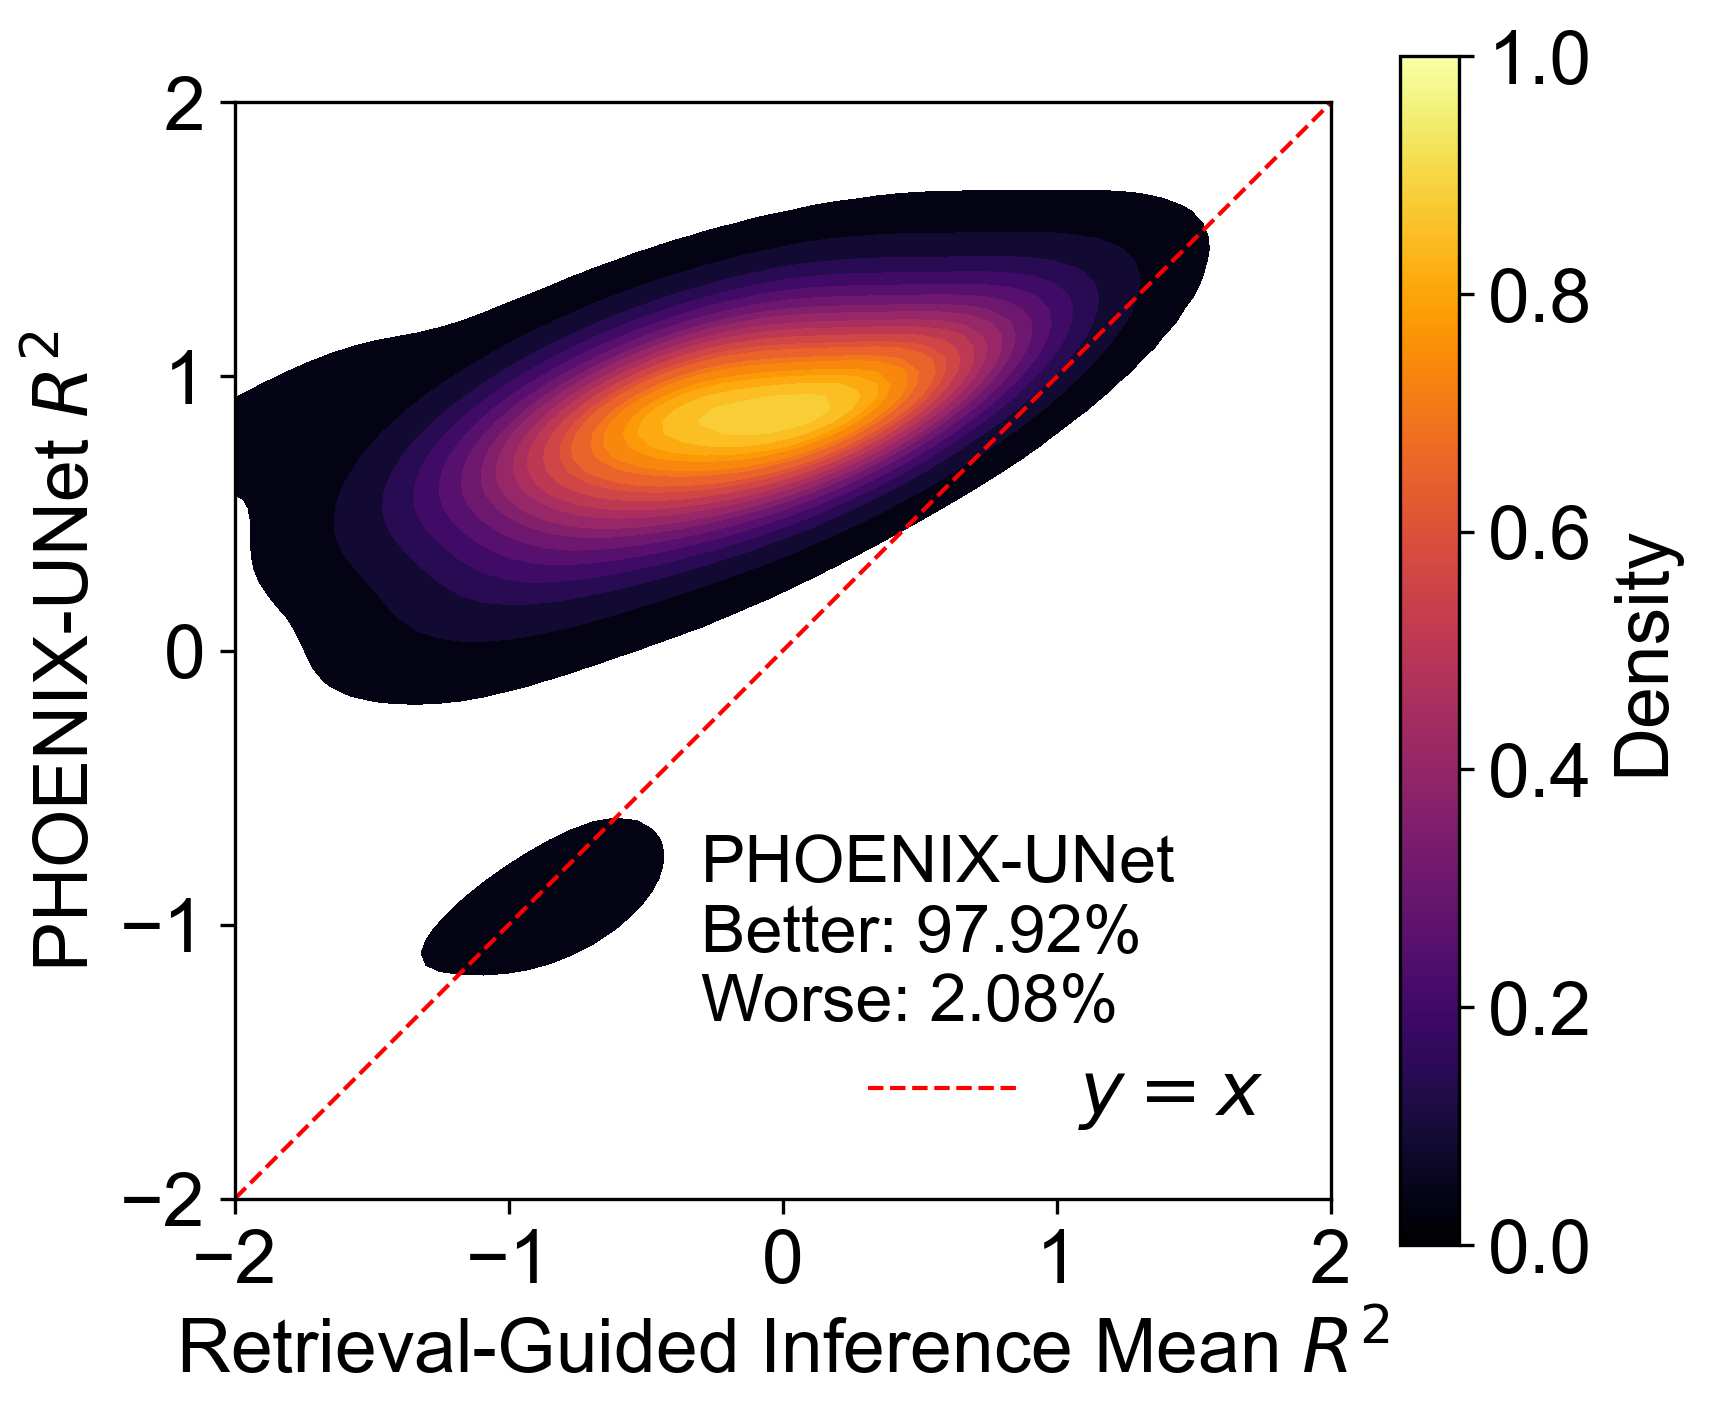

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import colors
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 18

metrics_name = 'r2'
df = df_select_xy_final_dir2_speed.copy()
x = df[f'mean_{metrics_name}']
y = df[f'dir_{metrics_name}']

mask_worse = y < x
frac_worse = mask_worse.sum() / len(df)
frac_better = 1 - frac_worse

camp_name = 'inferno'
plt.figure(figsize=(6, 6), dpi=300)
norm = colors.Normalize(vmin=0, vmax=1)
kde = sns.kdeplot(
    x=x, y=y,
    fill=True, cmap=camp_name,
    levels=20, thresh=0.05,
    norm=norm)
sm = plt.cm.ScalarMappable(cmap=camp_name, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.75)
cbar.set_label('Density')
plt.plot([-2, 2], [-2, 2], '--r', lw=1,
         label=r'$\mathit{y=x}$')

plt.text(
    -0.3, -1.35,
    rf'PHOENIX-UNet' + '\n' +
    rf'Better: {frac_better*100:.2f}%' + '\n' +
    rf'Worse: {frac_worse*100:.2f}%',
    color='black', fontdict={'size': 16})

plt.xlabel(r'Retrieval-Guided Inference Mean $\mathit{R}^2$')
plt.ylabel(r'PHOENIX-UNet $\mathit{R}^2$')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig('../fig_figures/search&pred/comparison_r2.png', dpi=300, bbox_inches='tight')
plt.savefig('../fig_figures/search&pred/comparison_r2.svg', dpi=300, format='svg', bbox_inches='tight')
plt.show()

C:\Users\15810\AppData\Local\Temp\ipykernel_53544\1413325396.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Method
PHOENIX-UNet\nPrediction            0.873690
Retrieval-Guided\nInference Best    0.249985
Retrieval-Guided\nInference Mean   -0.231522
Name: R2, dtype: float64


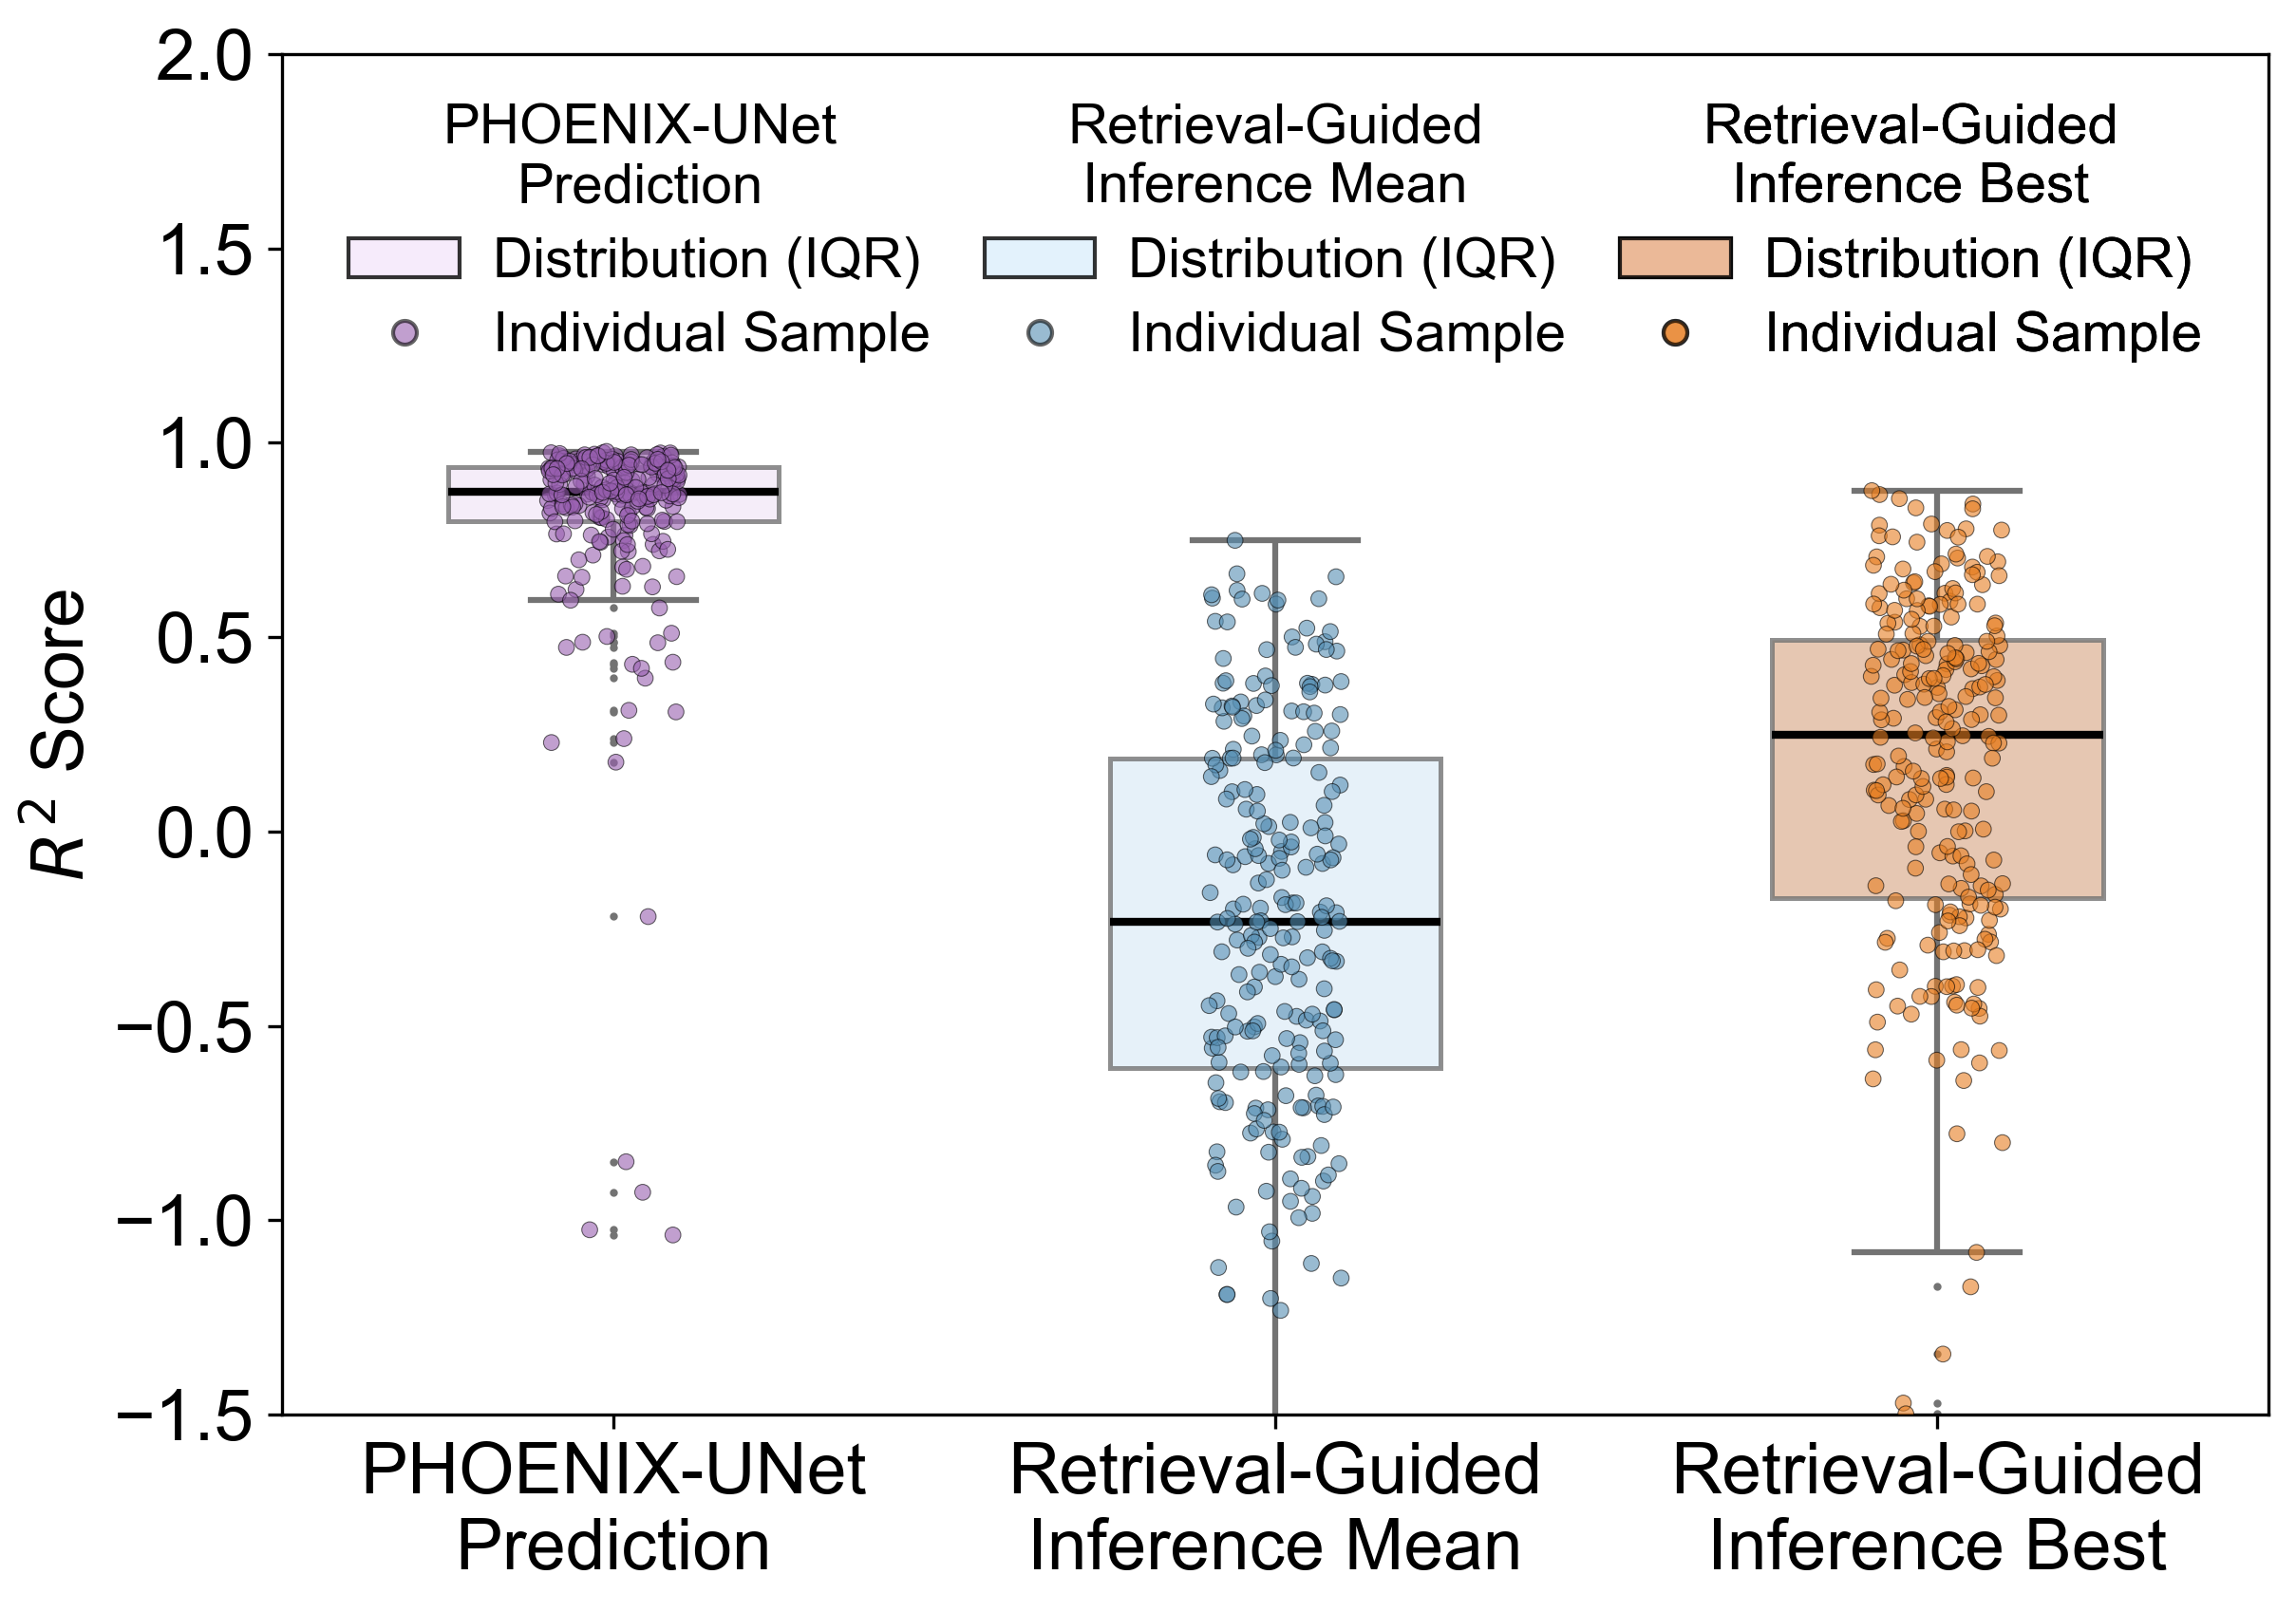

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 18

df = pd.read_csv('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2_1022/source_test_metrics_trues_dir2_wind.csv')
metrics_to_plot = ['dir_r2', 'mean_r2', 'max_r2']
rename_dict = {
    'dir_r2': 'PHOENIX-UNet\nPrediction',
    'mean_r2': 'Retrieval-Guided\nInference Mean',
    'max_r2': 'Retrieval-Guided\nInference Best'
}

df_melt = df[metrics_to_plot].melt(var_name='Method', value_name='R2')
df_melt['Method'] = df_melt['Method'].map(rename_dict)

custom_palette_box = ["#f4e6fa", "#dceffc", "#ebb794"]
custom_palette_dot = ["#985fb0", "#558eb3", "#e67e22"]

fig, ax = plt.subplots(figsize=(8.5, 6), dpi=300)
sns.boxplot(
    data=df_melt, x='Method', y='R2',
    palette=custom_palette_box,
    width=0.5,
    linewidth=1.2,
    fliersize=1,
    boxprops=dict(alpha=0.8),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    ax=ax
)
sns.stripplot(
    data=df_melt, x='Method', y='R2',
    hue='Method', palette=custom_palette_dot,
    dodge=False, size=4, jitter=True,
    alpha=0.6, edgecolor='k', linewidth=0.25,
    legend=False, ax=ax
)

ax.set_ylabel(r"$\mathit{R}^2$ Score")
ax.set_xlabel("")
ax.set_ylim(-1.5, 2)
fig.subplots_adjust(right=0.78)

print(df_melt.groupby('Method')['R2'].median())

methods = list(rename_dict.values())
for i, method in enumerate(methods):
    box_patch = mpatches.Patch(facecolor=custom_palette_box[i], edgecolor='black', alpha=0.8)
    dot_marker = mlines.Line2D([], [], color=custom_palette_dot[i], marker='o', linestyle='None',
                               markersize=6, markeredgecolor='k', alpha=0.6)
    leg = ax.legend(
        handles=[box_patch, dot_marker],
        labels=['Distribution (IQR)', 'Individual Sample'],
        title=method,
        title_fontsize=14,
        fontsize=14,
        loc='upper center',
        bbox_to_anchor=(0.18 + i * 0.32, 1),
        frameon=False,
        handletextpad=0.6,
        labelspacing=0.4,
    )
    leg.set_title(method)
    leg.get_title().set_ha('center')
    fig.add_artist(leg)

plt.tight_layout()
plt.savefig('../fig_figures/search&pred/boxplot_r2_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('../fig_figures/search&pred/boxplot_r2_comparison.svg', dpi=300, format='svg', bbox_inches='tight')
plt.show()


Method
PHOENIX-UNet\nPrediction            0.109541
Retrieval-Guided\nInference Best    0.682231
Retrieval-Guided\nInference Mean    1.032996
Name: mse, dtype: float64


C:\Users\15810\AppData\Local\Temp\ipykernel_53544\146962478.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


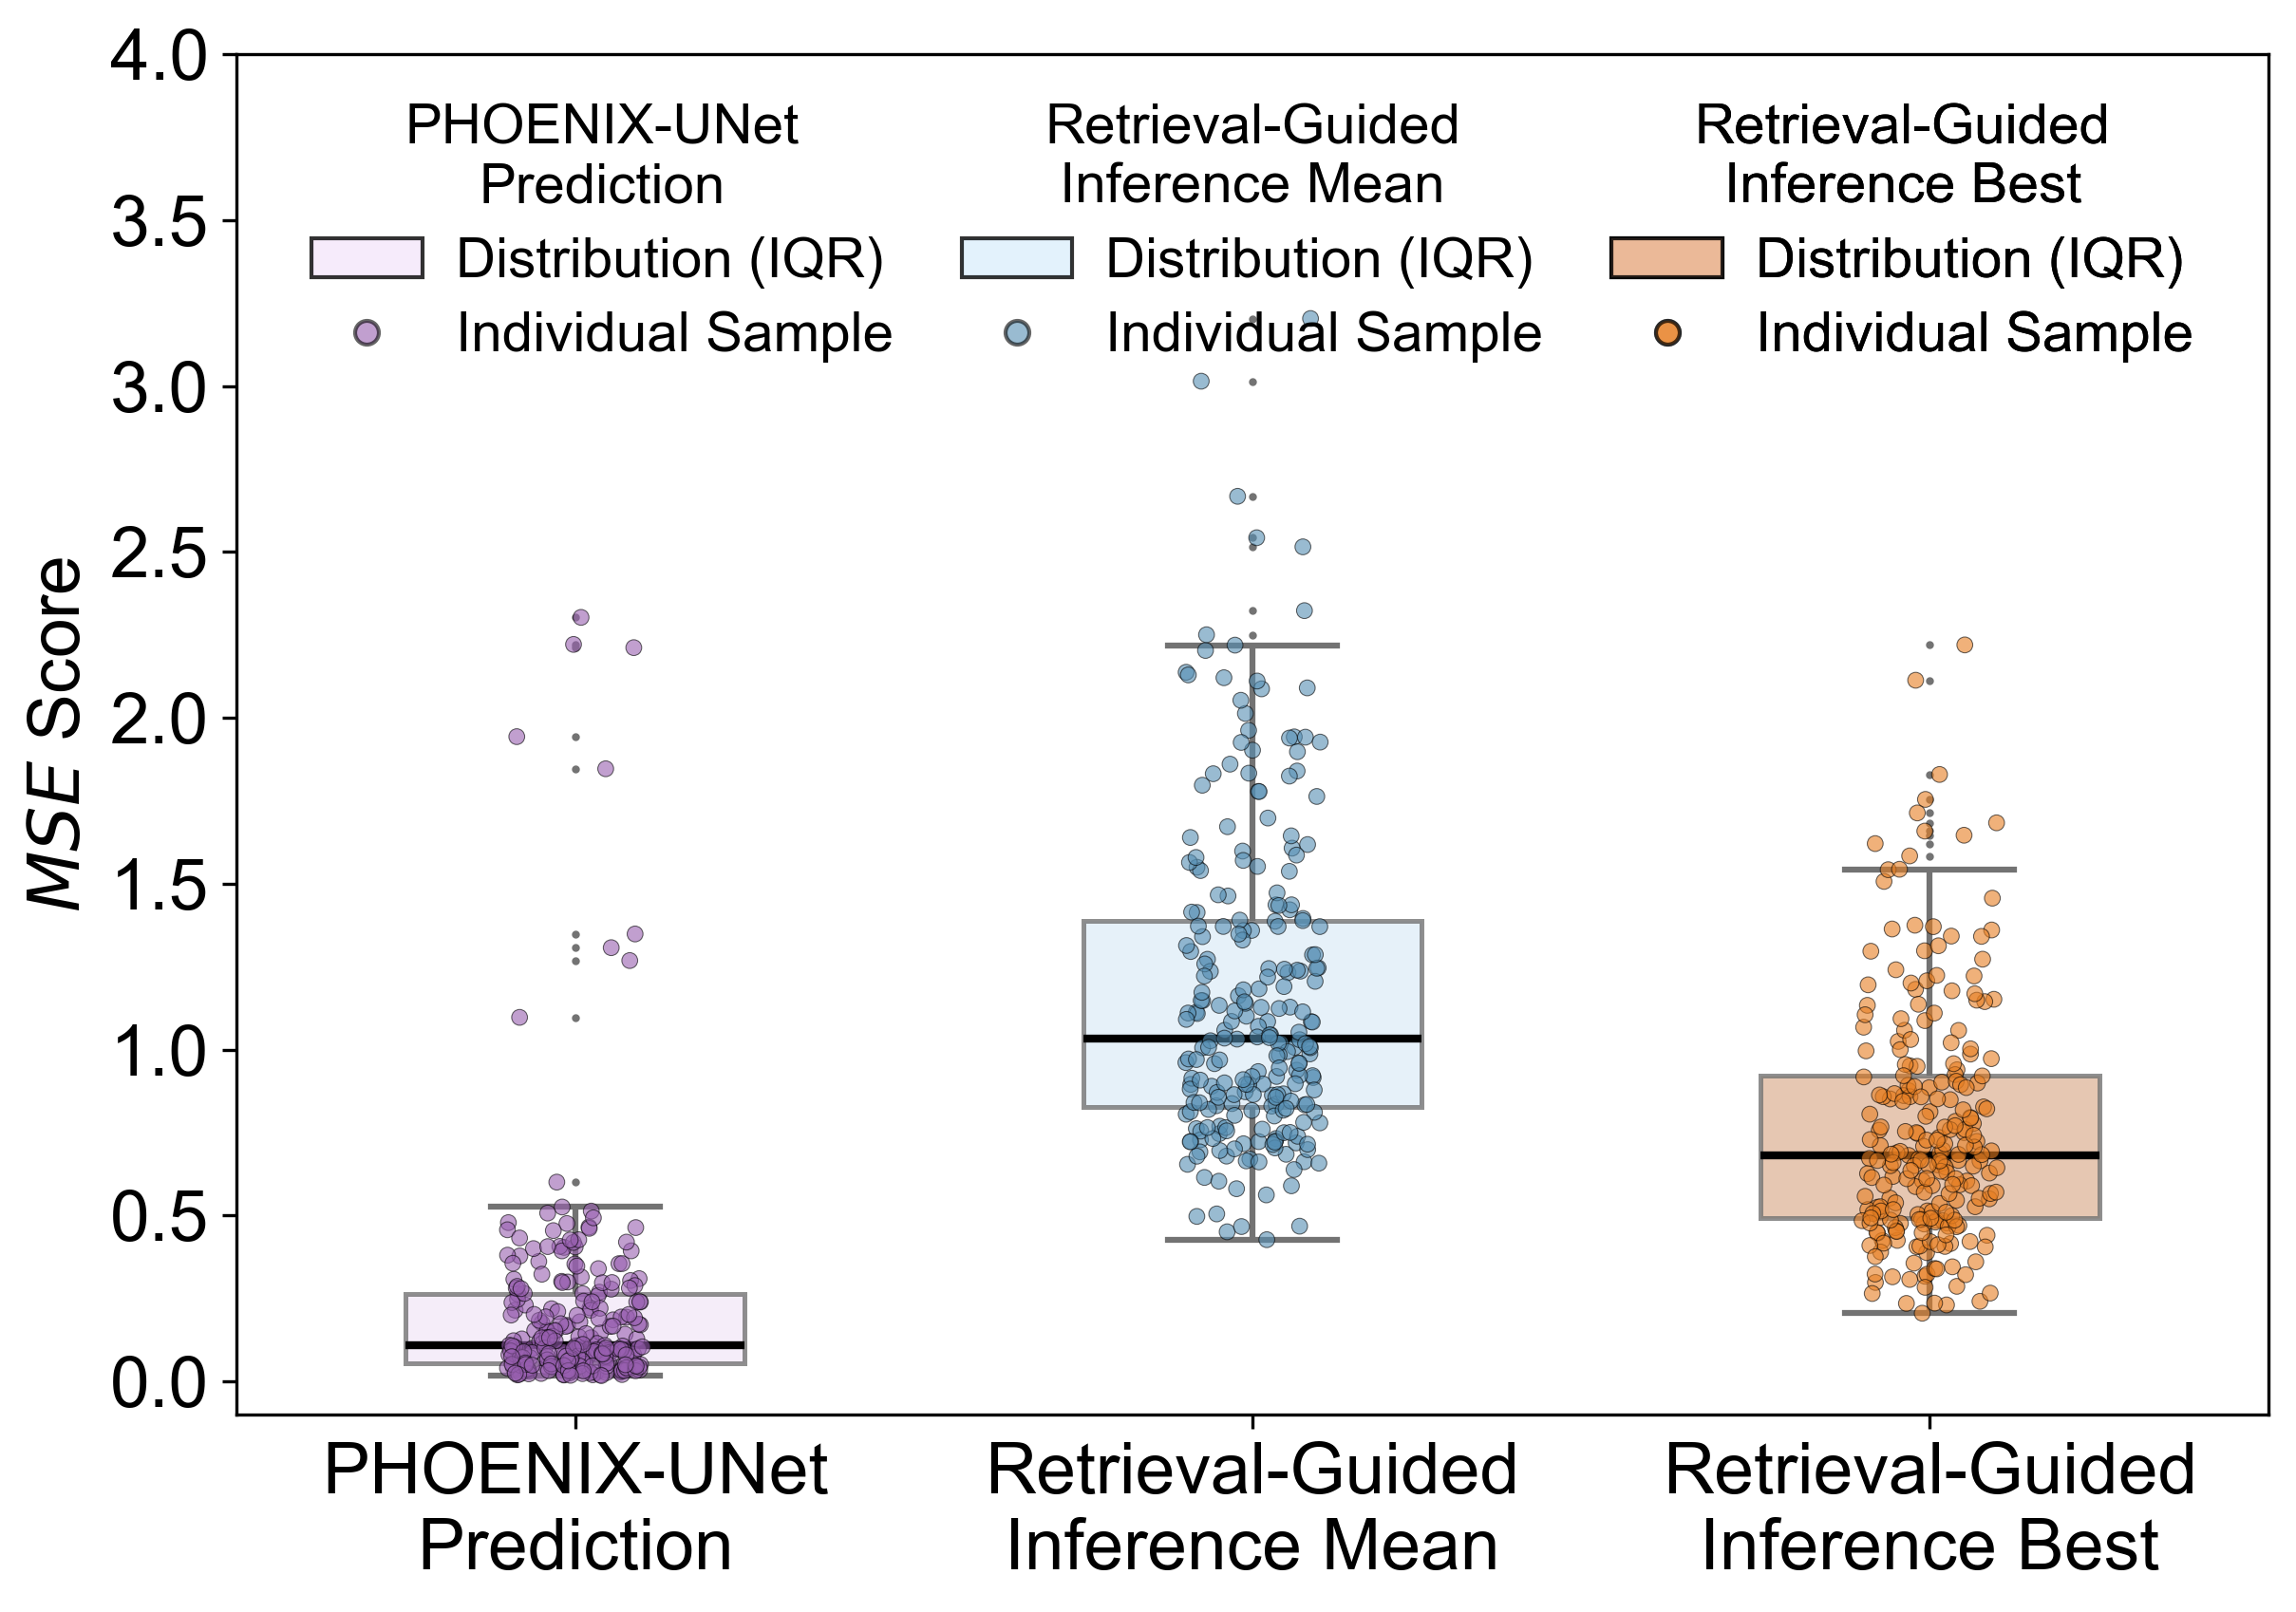

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 18

df = pd.read_csv('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2_1022/source_test_metrics_trues_dir2_wind.csv')
metrics_name = 'mse'
ylim_metrics = {
    'rmse': (-0.1, 3),
    'nmse': (-0.1, 30),
    'mae': (-0.1, 2),
    'mse': (-0.1, 4),
}
metrics_to_plot = [f'dir_{metrics_name}', f'mean_{metrics_name}',
                   f'max_{metrics_name}']
rename_dict = {
    f'dir_{metrics_name}': 'PHOENIX-UNet\nPrediction',
    f'mean_{metrics_name}': 'Retrieval-Guided\nInference Mean',
    f'max_{metrics_name}': 'Retrieval-Guided\nInference Best'
}

df_melt = df[metrics_to_plot].melt(var_name='Method', value_name=metrics_name)
df_melt['Method'] = df_melt['Method'].map(rename_dict)
print(df_melt.groupby('Method')[metrics_name].median())

custom_palette_box = ["#f4e6fa", "#dceffc", "#ebb794"]
custom_palette_dot = ["#985fb0", "#558eb3", "#e67e22"]

fig, ax = plt.subplots(figsize=(8.5, 6), dpi=300)
sns.boxplot(
    data=df_melt, x='Method', y=metrics_name,
    palette=custom_palette_box,
    width=0.5,
    linewidth=1.2,
    fliersize=1,
    boxprops=dict(alpha=0.8),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    ax=ax
)
sns.stripplot(
    data=df_melt, x='Method', y=metrics_name,
    hue='Method', palette=custom_palette_dot,
    dodge=False, size=4, jitter=True,
    alpha=0.6, edgecolor='k', linewidth=0.25,
    legend=False, ax=ax
)

ylabel_name = f'${metrics_name.upper()}$ Score'
ax.set_ylabel(ylabel_name)
ax.set_xlabel("")
ax.set_ylim(ylim_metrics[metrics_name])
fig.subplots_adjust(right=0.78)


methods = list(rename_dict.values())
for i, method in enumerate(methods):
    box_patch = mpatches.Patch(facecolor=custom_palette_box[i], edgecolor='black', alpha=0.8)
    dot_marker = mlines.Line2D([], [], color=custom_palette_dot[i], marker='o', linestyle='None',
                               markersize=6, markeredgecolor='k', alpha=0.6)
    leg = ax.legend(
        handles=[box_patch, dot_marker],
        labels=['Distribution (IQR)', 'Individual Sample'],
        title=method,
        title_fontsize=14,
        fontsize=14,
        loc='upper center',
        bbox_to_anchor=(0.18 + i * 0.32, 1),
        frameon=False,
        handletextpad=0.6,
        labelspacing=0.4,
    )
    leg.set_title(method)
    leg.get_title().set_ha('center')
    fig.add_artist(leg)

plt.tight_layout()
plt.savefig(f'../fig_figures/search&pred/boxplot_{metrics_name}_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../fig_figures/search&pred/boxplot_{metrics_name}_comparison.svg', dpi=300, format='svg', bbox_inches='tight')
plt.show()


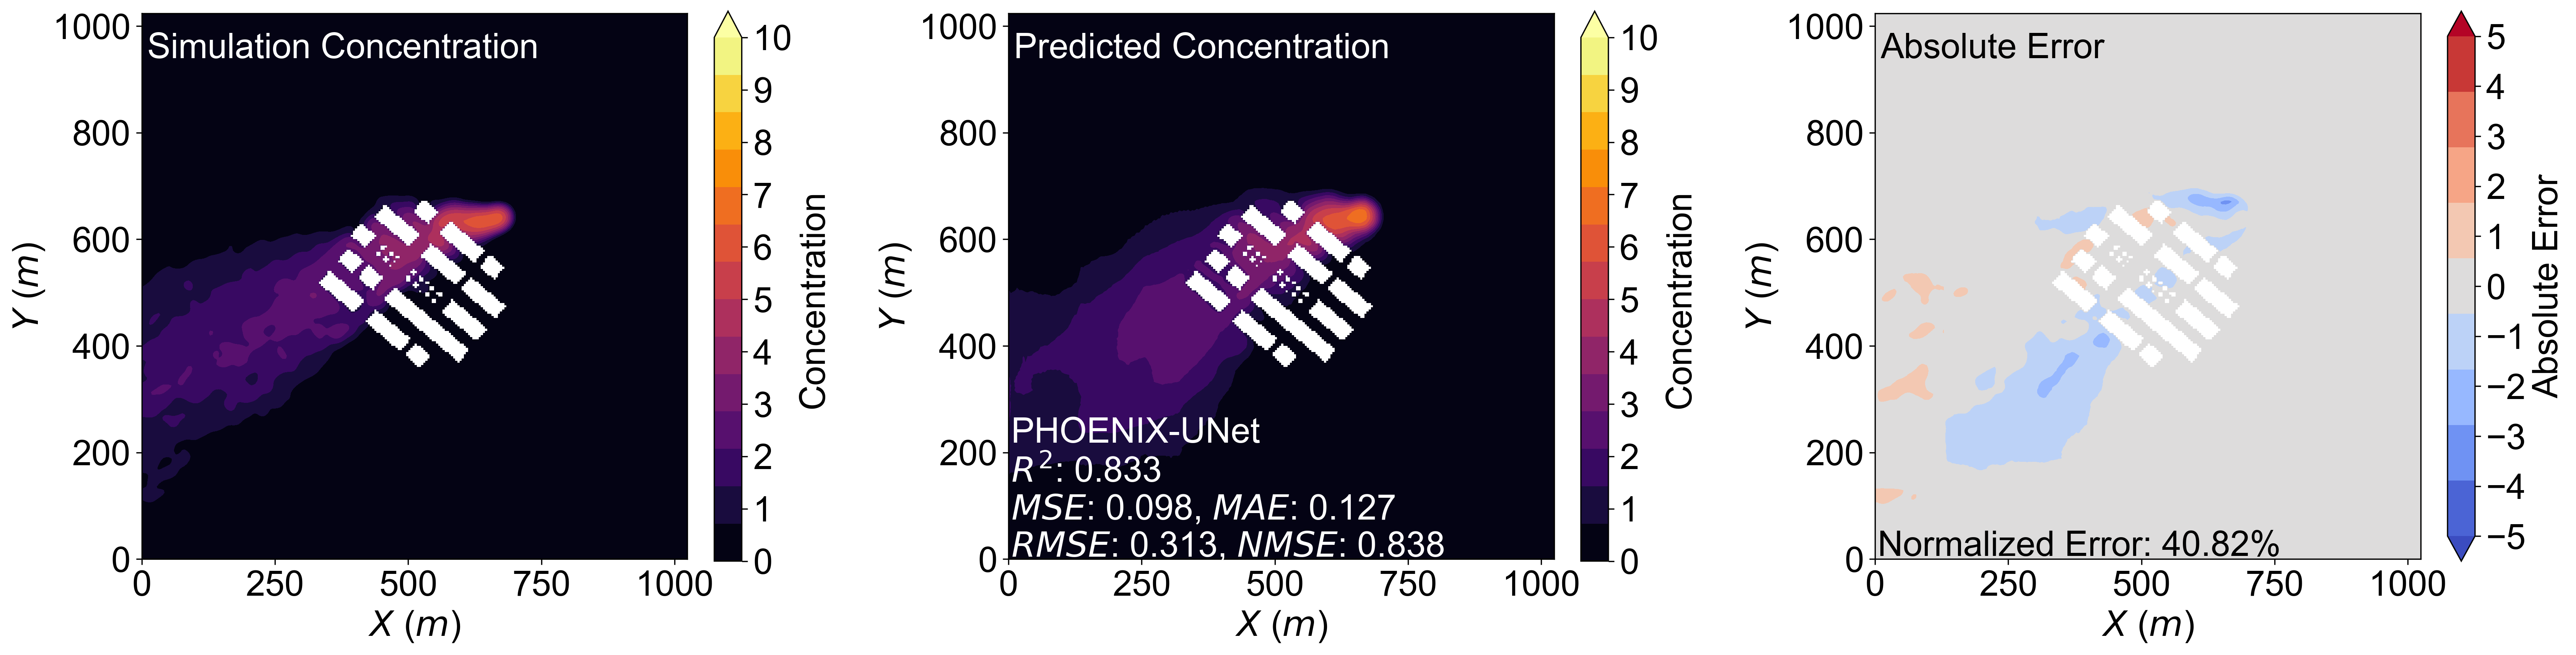

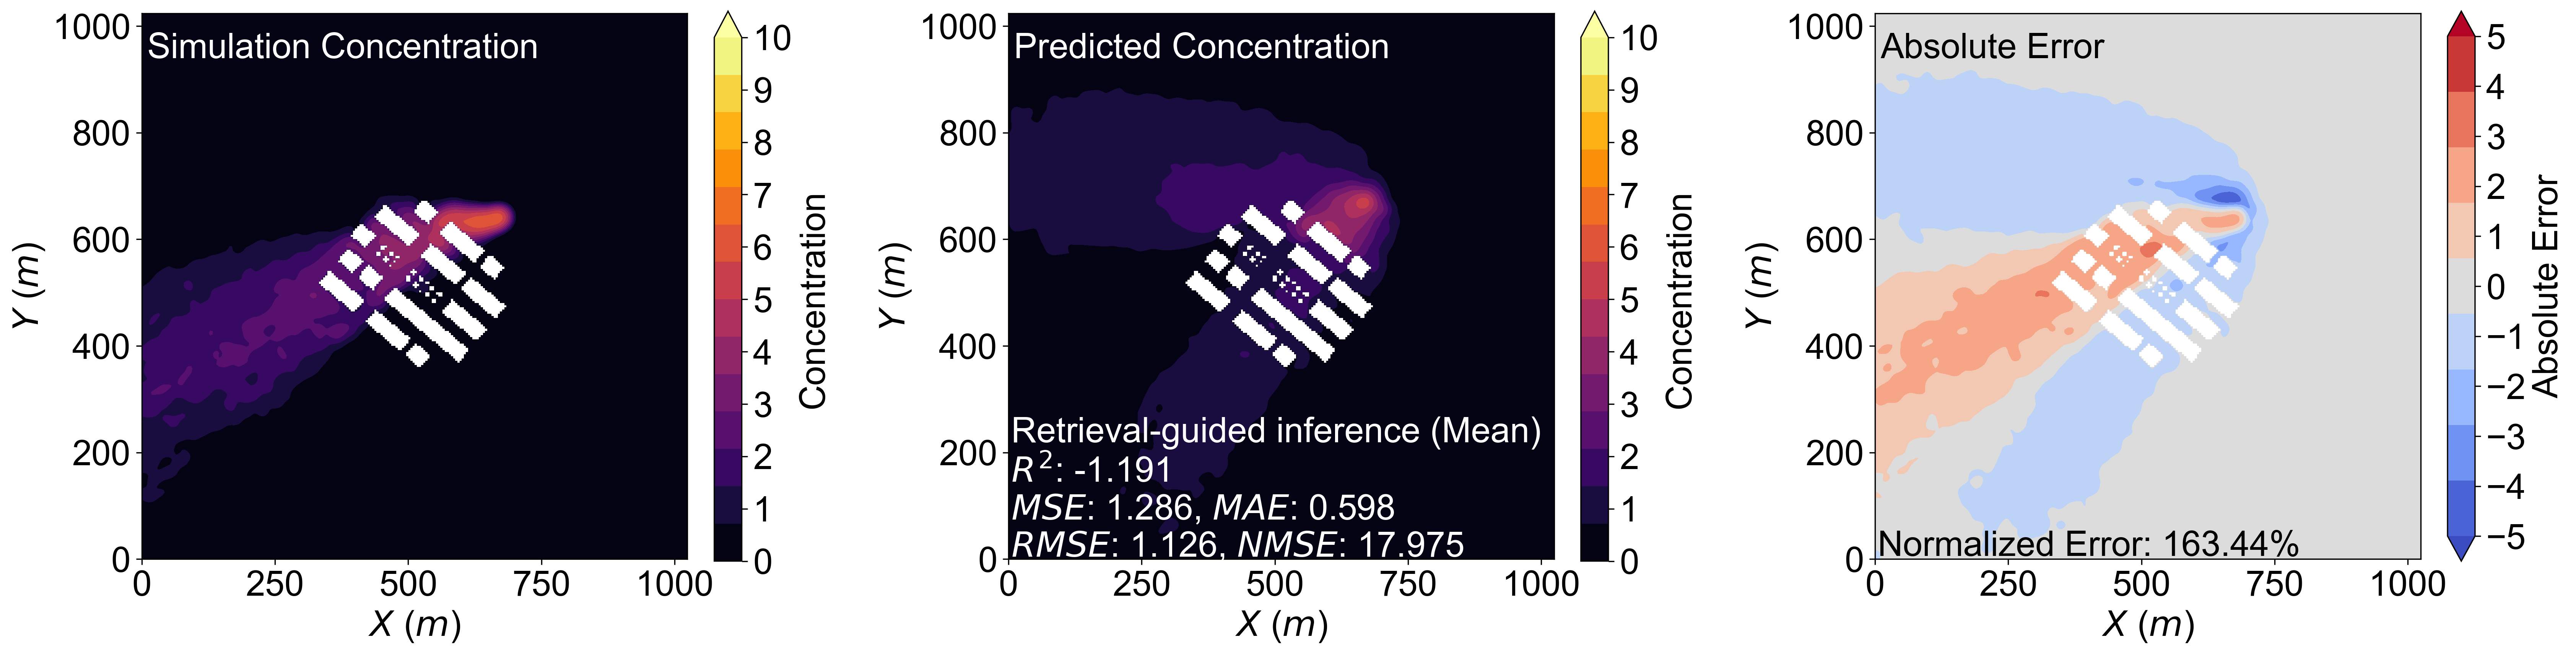

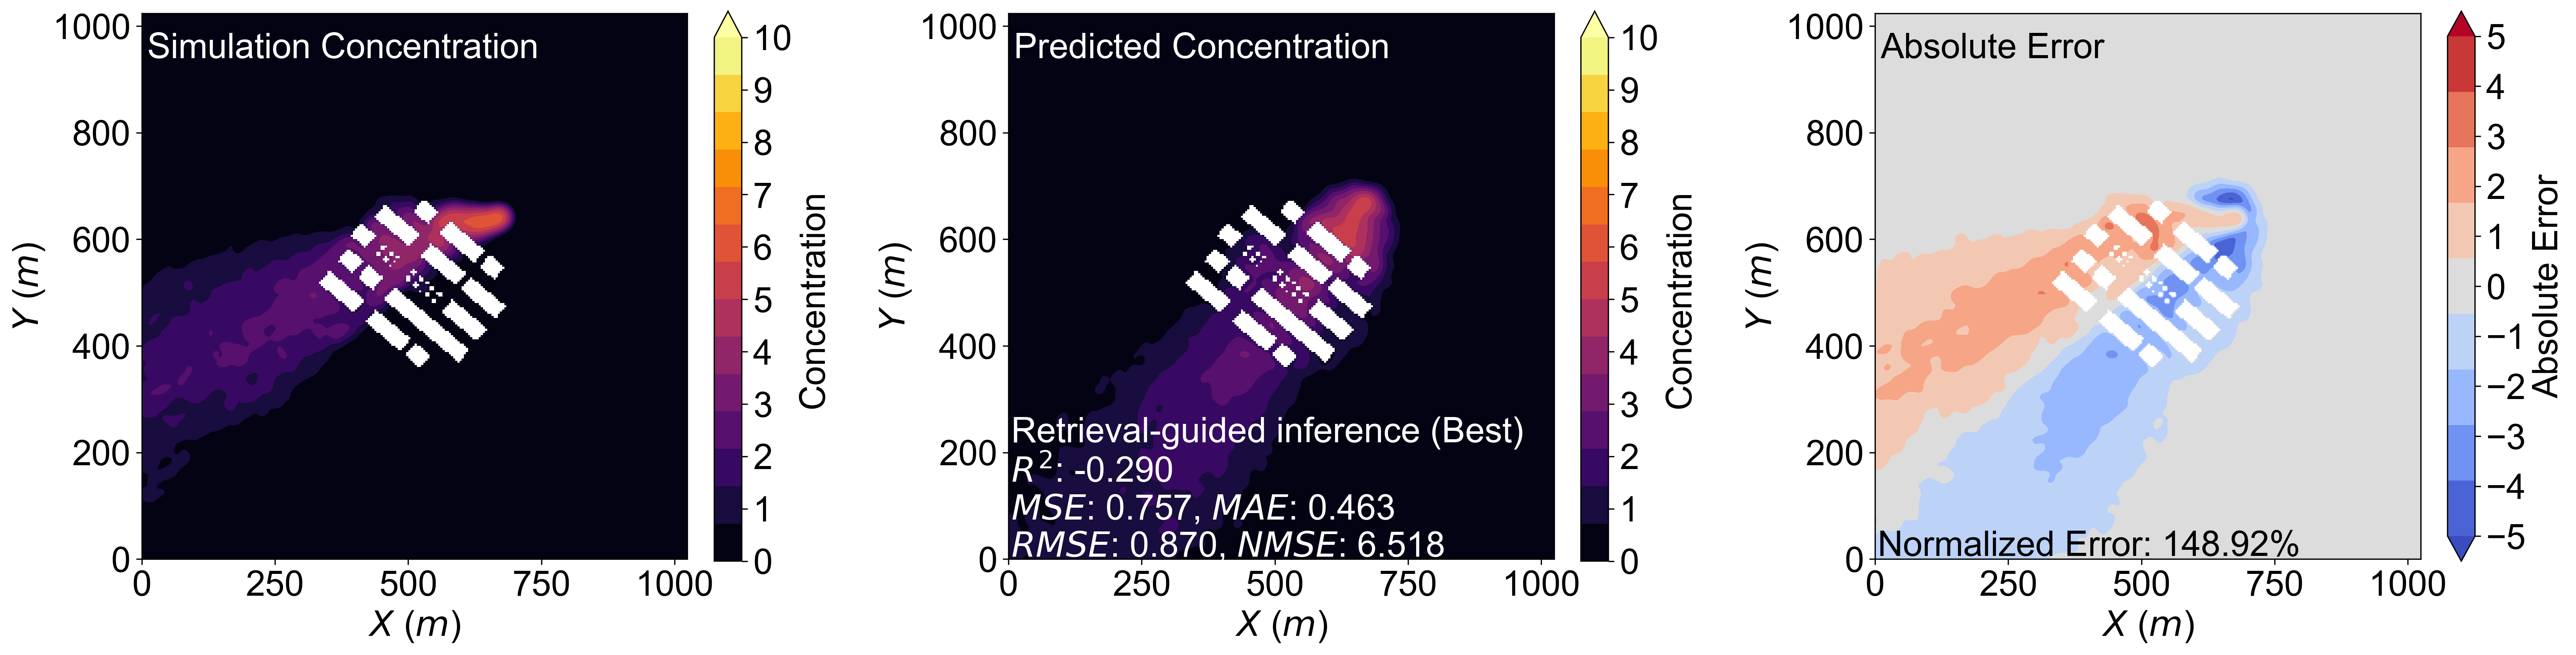

In [ ]:
from support_fuc import get_building_area
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 22

base_idx = 139 # down
# base_idx = 137 # middle
# base_idx = 141 # up
situation = "situation6"
test_preds = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2/all_test_pred2.npz')['preds'].squeeze(1)
test_trues = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2/all_test_pred2.npz')['trues'].squeeze(1)
train_pred_npz = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/train_pred_npz/train_pred_epoch100.npz')
# train_trues = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/train_pred_npz/all_processed.npz')
train_trues = np.load('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/train_pred_npz/all_processed_1022.npz')
df = pd.read_csv('../results/exp2/CNN_bs64_lr0.001_img256_k0_lossmse_ch32_dim48_depth5/pred_npz/test_pred_npz2/source_test_metrics_trues_dir2_wind.csv')
build_data_256, non_building_mask = get_building_area()
building_mask = np.where(build_data_256 > 0, 1, 0)
true_dir = np.where(test_trues[base_idx] > 0, test_trues[base_idx], 0) * non_building_mask
pred_dir = np.where(test_preds[base_idx] > 0, test_preds[base_idx], 0) * non_building_mask
# true_dir = test_trues[base_idx]
# pred_dir = test_preds[base_idx]
plot_comparison_special(true_dir, pred_dir, base_idx,
                # title_prefix=f"Idx{base_idx} Predicted Concentration",
                title_prefix="PHEN-UNet",
                situation=situation, type_name='pred',
                return_metrics=False, plot_flag=True)

# mean idx
mean_r2 = df.loc[df['base_idx'] == base_idx, 'mean_r2'].values[0]
mean_mse = df.loc[df['base_idx'] == base_idx, 'mean_mse'].values[0]
mean_mae = df.loc[df['base_idx'] == base_idx, 'mean_mae'].values[0]
mean_rmse = df.loc[df['base_idx'] == base_idx, 'mean_rmse'].values[0]
mean_nmse = df.loc[df['base_idx'] == base_idx, 'mean_nrmse'].values[0]

left_max_idx = df.loc[df['base_idx'] == base_idx, 'left_max_idx'].values[0]
left_max_col = df.loc[df['base_idx'] == base_idx, 'left_max_col'].values[0]
right_max_idx = df.loc[df['base_idx'] == base_idx, 'right_max_idx'].values[0]
right_max_col = df.loc[df['base_idx'] == base_idx, 'right_max_col'].values[0]
left_max_simulation = np.where(train_trues[left_max_col] > 0, train_trues[left_max_col], 0) * non_building_mask
right_max_simulation = np.where(train_trues[right_max_col] > 0, train_trues[right_max_col], 0) * non_building_mask
mean_con = np.mean([left_max_simulation, right_max_simulation], axis=0)
plot_comparison_special(true_dir, mean_con, base_idx,
                # title_prefix=f"Idx{base_idx} Mean Concentration",
                title_prefix="Retrieval-guided inference (Mean)",
                situation=situation, type_name='mean',
                return_metrics=False, plot_flag=True,
                mean_flag=True, mean_r2=mean_r2, mean_mse=mean_mse,
                mean_mae=mean_mae, mean_rmse=mean_rmse,
                mean_nmse=mean_nmse)

max_idx = df.loc[df['base_idx'] == base_idx, 'max_r2_idx'].values[0]
max_col = df.loc[df['base_idx'] == base_idx, 'max_r2_col'].values[0]
max_simulation = np.where(train_trues[max_col] > 0, train_trues[max_col], 0) * non_building_mask
plot_comparison_special(true_dir, max_simulation, base_idx,
                # title_prefix=f"Idx{base_idx} Max Concentration",
                title_prefix="Retrieval-guided inference (Best)",
                situation=situation, type_name='max',
                return_metrics=False, plot_flag=True)
